<a href="https://colab.research.google.com/github/DEEPAK4151/python-practice-colab1/blob/main/EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import kagglehub
path = kagglehub.dataset_download("sidramazam/e-commerce-sales-performance-analysis")

Using Colab cache for faster access to the 'e-commerce-sales-performance-analysis' dataset.


In [3]:
df=pd.read_csv(f"{path}/ecommerce_sales_data.csv")



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [5]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0


In [6]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [18]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.sample(5)

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
963,2022-03-20,Camera,Electronics,East,5,4485,1324.49
2644,2024-05-30,Headphones,Accessories,East,7,1785,233.77
1702,2024-07-30,Printer,Office,East,4,2396,608.50
1304,2023-06-14,Printer,Office,South,9,2178,382.67
654,2023-06-13,Printer,Office,East,1,1176,182.07


In [8]:
df.shape

(3500, 7)

In [9]:
df.corr(numeric_only=True)

,Quantity,Sales,Profit
Quantity,1.000000,0.662468,0.560651
Sales,0.662468,1.000000,0.832826
Profit,0.560651,0.832826,1.000000


In [17]:
df1=df.groupby(['Category','year'])

In [18]:
df1.size().sort_values(ascending=False)

Category     year
Electronics  2023    604
             2024    599
             2022    539
Accessories  2024    485
             2023    470
             2022    446
Office       2023    130
             2024    118
             2022    109
dtype: int64

In [66]:
df1['Profit'].sum()

Category     year
Accessories  2022    238187.58
             2023    261626.94
             2024    236270.22
Electronics  2022    286236.30
             2023    331270.15
             2024    305679.14
Office       2022     48433.10
             2023     73969.33
             2024     62992.45
Name: Profit, dtype: float64

In [13]:
import pandas as pd

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce').dt.date

In [68]:
df1.head(1)

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,month,year
0,2024-12-31,Printer,Office,North,4,3640,348.93,12,2024
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,11,2022
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,5,2022
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,3,2024
5,2023-12-01,Camera,Electronics,West,1,524,106.35,12,2023
6,2023-10-09,Headphones,Accessories,North,7,6167,1027.98,10,2023
13,2024-02-03,Smartphone,Electronics,West,5,4205,585.29,2,2024
23,2023-11-13,Printer,Office,North,3,3477,939.20,11,2023
30,2022-10-21,Printer,Office,West,8,1376,152.10,10,2022


In [14]:
df['month']=pd.to_datetime(df['Order Date'],errors='coerce').dt.month

In [15]:
df['year']=pd.to_datetime(df['Order Date'],errors='coerce').dt.year

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df2=df.groupby(['year'])

In [31]:
df2['Sales'].sum()

,Sales
year,
2022,3255970
2023,3786592
2024,3625319


In [32]:
df2['Profit'].sum()

,Profit
year,
2022,572856.98
2023,666866.42
2024,604941.81


/tmp/ipykernel_271/1705408248.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['year'])


<Axes: xlabel='year', ylabel='Density'>

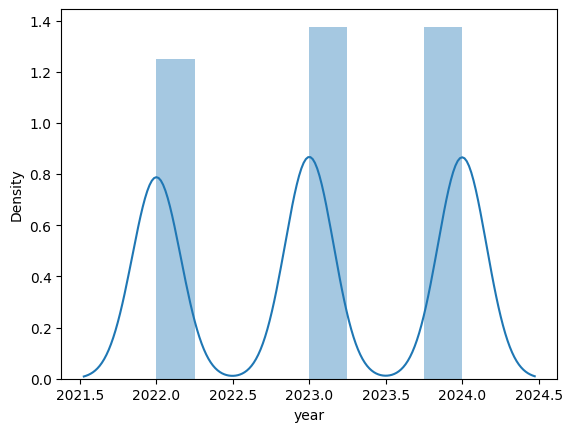

In [35]:
sns.distplot(df['year'])

In [36]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
East,464888.46
North,426314.75
South,458103.27
West,495358.73


In [37]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Accessories,4247591
Electronics,5326074
Office,1094216


In [39]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Product Name,
Camera,1177381
Monitor,1160048
Printer,1094216
Mouse,1074398
Smartphone,1069681
Smartwatch,1049211
Keyboard,1024507
Tablet,1023928
Laptop,1005873


In [40]:
df.groupby('Category')['Sales'].sum().plt(kind='bar')

AttributeError: 'Series' object has no attribute 'plt'

In [48]:
df.groupby('month')['Sales'].sum().sort_values(ascending=False).head(3
)



,Sales
month,
5,1034687
1,967614
12,959102


In [47]:
df.groupby('month')['Sales'].sum().sort_values(ascending=False).tail(3
)

,Sales
month,
6,839805
4,821876
2,702414


In [49]:
df.corr(numeric_only=True)

,Quantity,Sales,Profit,month,year
Quantity,1.000000,0.662468,0.560651,0.013499,0.004026
Sales,0.662468,1.000000,0.832826,0.011568,0.005812
Profit,0.560651,0.832826,1.000000,0.004462,-0.017394
month,0.013499,0.011568,0.004462,1.000000,0.031510
year,0.004026,0.005812,-0.017394,0.031510,1.000000


##Customer Analysis

In [ ]:
df1.groupby('Customer')

In [50]:
df.to_csv('customer_performance.csv')

In [14]:
!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0.2
    Uninstalling multimethod-2.0.2:
      Successfully uninstalled multimethod-2.0.2
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [4]:
import pandas as pd
from ydata_profiling import ProfileReport
prof=ProfileReport(df)
prof.to_file(output_file='output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 14.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]